# 🌲 Random Forest Regression

## 🎯 Objective

In this notebook, we will learn how the **Random Forest Regressor** works, train it on the California Housing dataset, evaluate its performance, and visualize the results.

---

# 📖 Theory

## What is Random Forest Regression?

Random Forest is an **ensemble learning algorithm** that combines many Decision Trees to make a prediction.

Instead of relying on one tree, it builds multiple trees and averages their predictions.

Final Prediction = Average of Predictions from All Trees

It reduces overfitting and usually performs much better than a single Decision Tree.

---

## How Random Forest Works

1. Draw multiple random samples (Bootstrap Sampling).
2. Train one Decision Tree on each sample.
3. At each split, consider only a random subset of features.
4. Make predictions from all trees.
5. Average all predictions.

---

## Advantages

- High Accuracy
- Reduces Overfitting
- Handles Non-linear Data
- Works with Large Datasets
- Provides Feature Importance

---

## Disadvantages

- Slower than Linear Regression
- Uses More Memory
- Less Interpretable than a Single Decision Tree

---

## Real World Applications

- House Price Prediction
- Stock Price Forecasting
- Medical Cost Prediction
- Sales Forecasting
- Demand Forecasting

---

# 📚 Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
data = fetch_california_housing()

X = data.data

y = data.target

In [3]:
df = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

df["Price"] = data.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
df.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64

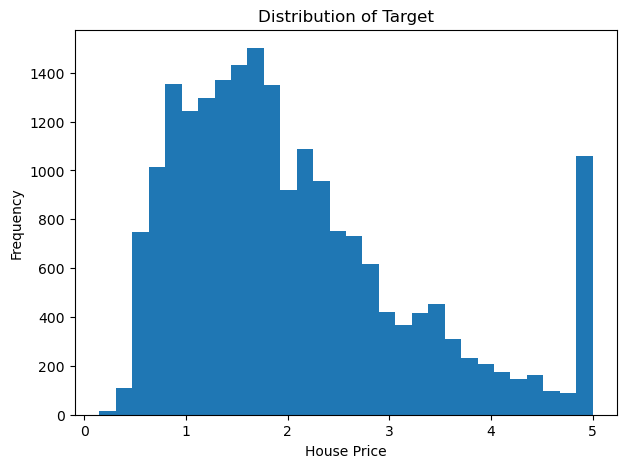

In [5]:
plt.figure(figsize=(7,5))

plt.hist(df["Price"], bins=30)

plt.xlabel("House Price")

plt.ylabel("Frequency")

plt.title("Distribution of Target")

plt.show()

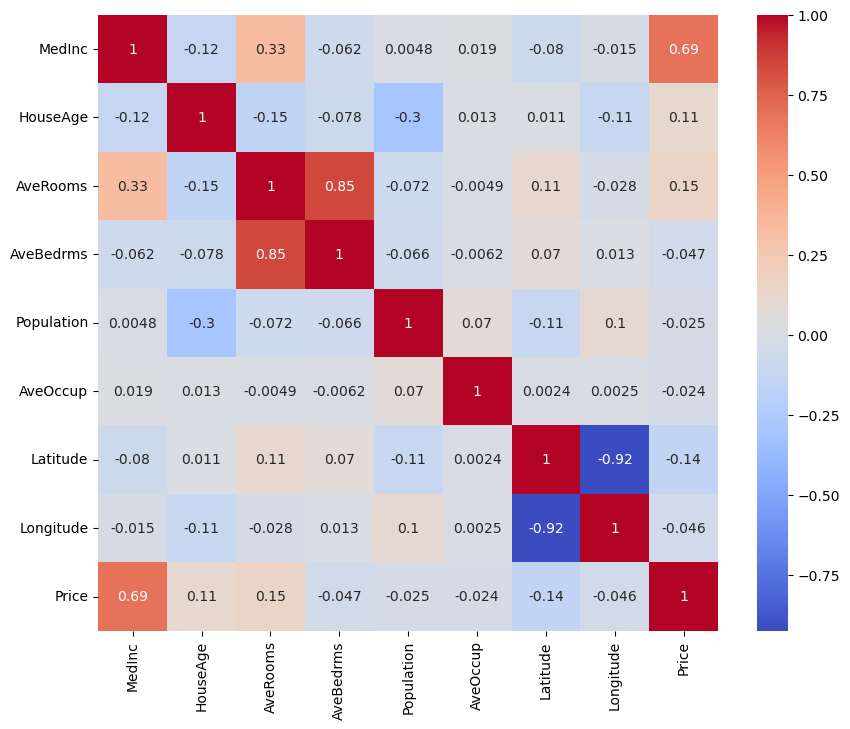

In [6]:
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [7]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42
)

In [8]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [9]:
model.fit(X_train,y_train)

RandomForestRegressor(random_state=42)

In [10]:
y_pred = model.predict(
    X_test
)

In [11]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)

print("MSE :", mse)

print("RMSE :", rmse)

print("R² Score :", r2)

MAE : 0.32754256845930246
MSE : 0.2553684927247781
RMSE : 0.5053399773665033
R² Score : 0.8051230593157366


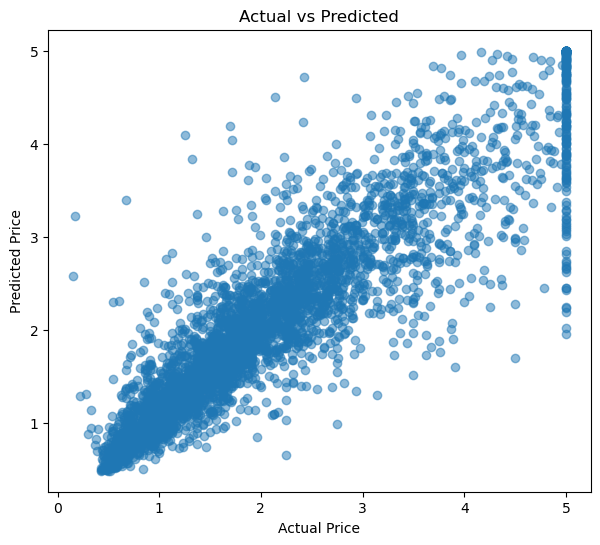

In [12]:
plt.figure(figsize=(7,6))

plt.scatter(

    y_test,

    y_pred,

    alpha=0.5
)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted")

plt.show()

In [13]:
results = pd.DataFrame({

    "Actual":y_test,

    "Prediction":y_pred

})

results.head(15)

,Actual,Prediction
0,0.47700,0.509500
1,0.45800,0.741610
2,5.00001,4.923257
3,2.18600,2.529610
4,2.78000,2.273690
5,1.58700,1.646920
6,1.98200,2.376050
7,1.57500,1.669320
8,3.40000,2.772971
9,4.46600,4.913459


Model : Random Forest Regressor

MAE  : Lower ✅

MSE  : Lower ✅

RMSE : Lower ✅

R²   : Higher ✅

Excellent Model

Suitable for Non-linear Data

Less Overfitting than Decision Tree